# EnerMap → PyPSA-LAEP
### The latest residential demand handoff · completed 23 September 2026

The starting point is simple: before deciding how to heat a place, we need to understand
its buildings. This notebook opens the latest completed EnerMap export and shows what
it can pass to the optimisation model: **where demand is, when it occurs, and how it
changes under alternative retrofit packages**.

This is the **57,300-dwelling Guildford-area stock**, not just the smaller town or
Westborough optimisation area. It is an uncalibrated, median-archetype release.
The optimisation notebooks alongside this one use an **earlier handoff**; they have
not yet been rerun with these data. Snapshot packaged 27 September 2026.

In [1]:
from pathlib import Path
import sys
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p/'src/showcase.py').exists())
sys.path.insert(0, str(ROOT/'src'))
from showcase import *
from IPython.display import display
style()
pd.set_option('display.precision', 3)

In [2]:
clusters = read('enermap/cluster_summary.csv')
annual = read('enermap/cluster_annual_totals.csv')
hourly = read('enermap/hourly_totals.csv', parse_dates=['timestamp_utc'])
zones = read('enermap/zone_centroids.csv')
completion = js('enermap/completion.json')
display(pd.Series({'Dwellings':int(clusters.dwelling_count.sum()),
                   'Building records':int(clusters.building_count.sum()),
                   'Demand clusters':len(clusters), 'Electricity zones':len(zones),
                   'Hourly steps per package':hourly.groupby('package_id').size().min()},name='Coverage').to_frame())
print('Completed:', completion['completed_utc'])
print('Case:', read('enermap/cases.csv').iloc[0].to_dict())

,Coverage
Dwellings,57300
Building records,50733
Demand clusters,2386
Electricity zones,320
Hourly steps per package,8760


Completed: 2026-09-23T22:06:25.890492+00:00
Case: {'case_id': 'GF2021_TMY_UNCAL_MEDIAN3_HOURLY_COP', 'year': 2021, 'description': 'Uncalibrated ISO 52016; typical cluster construction at three exact median areas; three paired stochastic draws per size; BREDEM annual usage; hourly ASHP COP; borough scope; no meter fitting'}


## 1 · Put the stock on the map

Each point is a **dwelling-weighted zone centroid**, not an individual building or an
electrical connection. The distinction between inferred substation zones and assumed
LSOA zones is important: neither is a substitute for a DNO connectivity model.

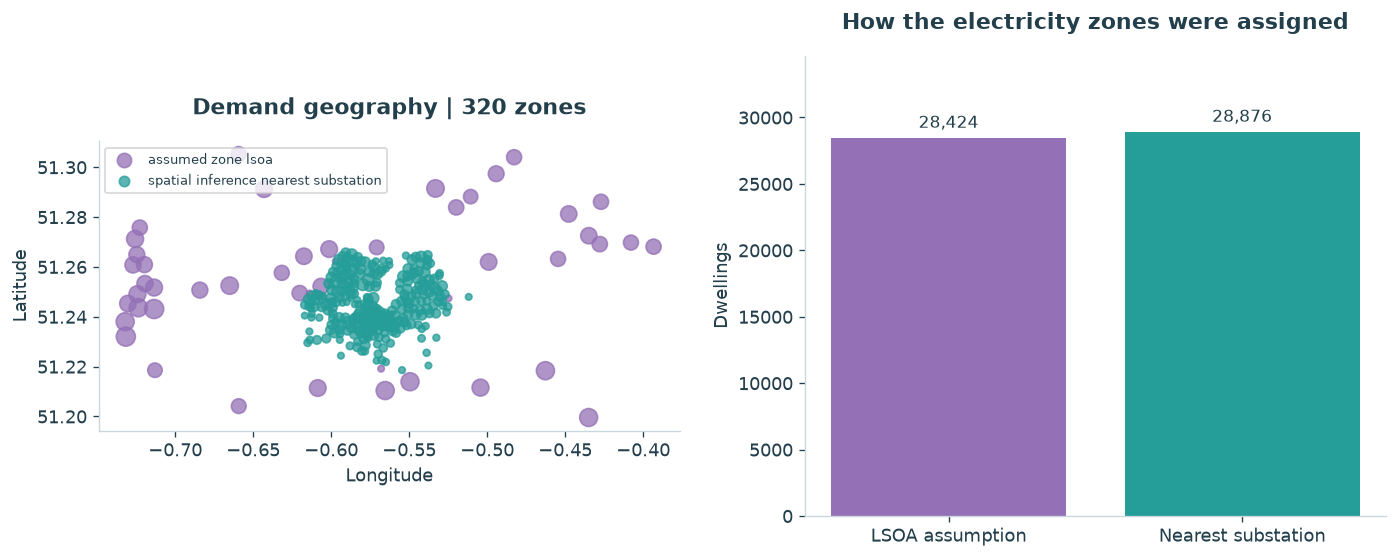

In [3]:
fig,ax=plt.subplots(1,2,figsize=(12,5))
for color,(method,g) in zip([PURPLE,TEAL],zones.groupby('network_assignment_method')):
    ax[0].scatter(g.lon,g.lat,s=15+g.dwellings/8,alpha=.75,color=color,label=method.replace('_',' '))
ax[0].set(xlabel='Longitude',ylabel='Latitude',title='Demand geography | 320 zones')
ax[0].set_aspect(1/np.cos(np.deg2rad(zones.lat.mean())))
ax[0].legend(fontsize=8,loc='upper left')
stock=clusters.groupby('network_assignment_method').dwelling_count.sum()
ax[1].bar(['LSOA assumption' if 'lsoa' in x else 'Nearest substation' for x in stock.index],stock.values,color=[PURPLE,TEAL])
ax[1].set(ylabel='Dwellings',title='How the electricity zones were assigned')
labelbars(ax[1]);ax[1].margins(y=.2)
finish(fig,'enermap_coverage')

## 2 · Three fabric states, one population

R0 is the baseline; R1 and R2 are alternative fabric packages. These bars ask what the
modelled stock would demand under each package envelope. **They are not an optimised
rollout**: the optimiser must still respect eligibility, quantities, costs and shares.
The space-heat profiles are simulated; the savings are not a fixed percentage imposed
afterwards. Hot-water and non-heating electricity must remain separate.

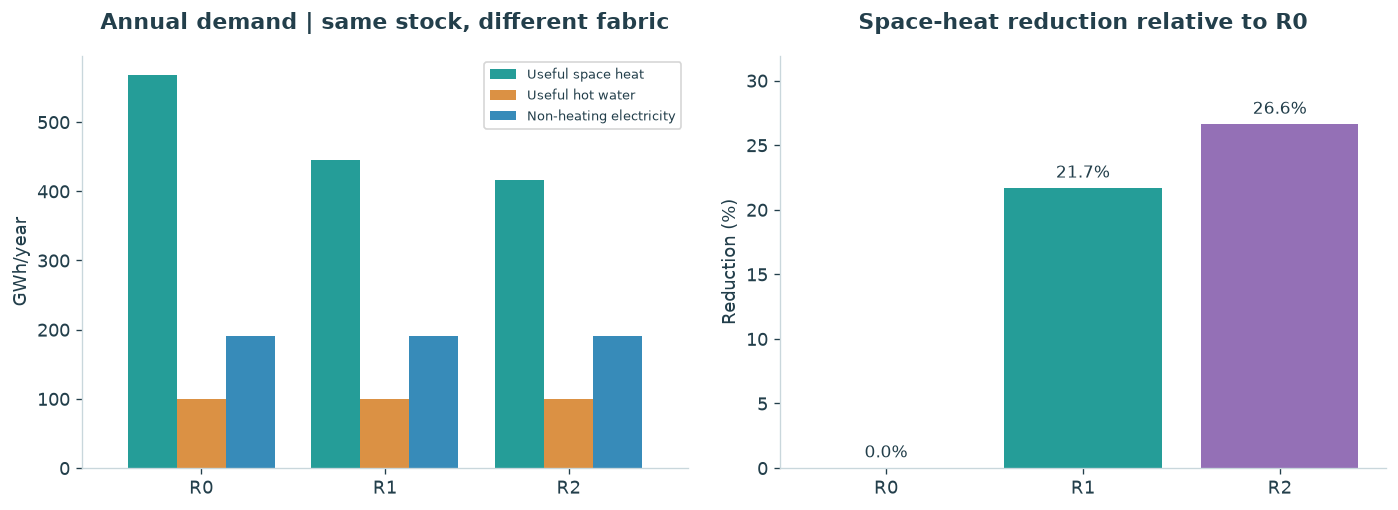

,space_heat_kWh,hot_water_kWh,non_heating_elec_kWh
Alternative package,,,
R0,567.57,99.42,190.81
R1,444.60,99.42,190.81
R2,416.56,99.42,190.81


In [4]:
totals=annual.groupby('package_id')[['space_heat_kWh','hot_water_kWh','non_heating_elec_kWh']].sum()/1e6
fig,ax=plt.subplots(1,2,figsize=(12,4.6))
totals.rename(columns={'space_heat_kWh':'Useful space heat','hot_water_kWh':'Useful hot water','non_heating_elec_kWh':'Non-heating electricity'}).plot.bar(ax=ax[0],color=[TEAL,GOLD,BLUE],rot=0,width=.8)
ax[0].set(title='Annual demand | same stock, different fabric',ylabel='GWh/year',xlabel='')
ax[0].legend(fontsize=8)
savings=(1-totals.space_heat_kWh/totals.loc['R0','space_heat_kWh'])*100
ax[1].bar(savings.index,savings.values,color=[GREY,TEAL,PURPLE]);labelbars(ax[1],'{:.1f}','%')
ax[1].set(title='Space-heat reduction relative to R0',ylabel='Reduction (%)');ax[1].margins(y=.2)
finish(fig,'enermap_packages')
display(totals.rename_axis('Alternative package').round(2))

## 3 · Timing is part of the handoff

The annual totals hide winter peaks and day-to-day variation. These profiles sum the
**actual exported cluster demand**, not a rescaled illustrative curve. The UTC label
is a fixed 8,760-hour model clock for local TMY weather; it should not be shifted for DST.

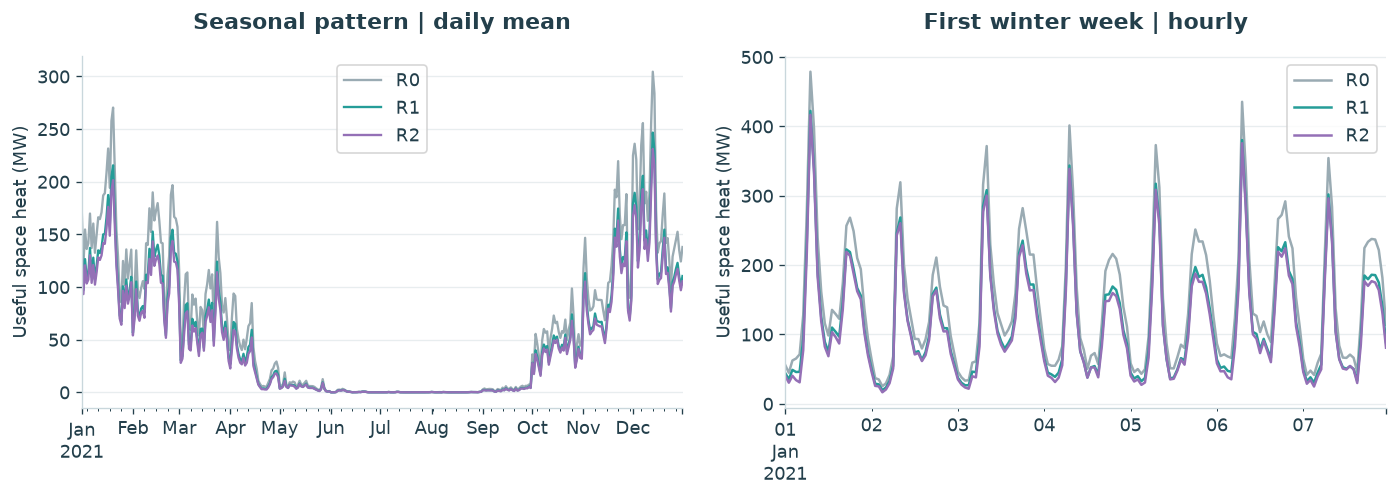

In [5]:
fig,ax=plt.subplots(1,2,figsize=(12,4.5))
for color,(package,g) in zip([GREY,TEAL,PURPLE],hourly.groupby('package_id')):
    series=g.set_index('timestamp_utc').space_heat_kw/1000
    series.resample('D').mean().plot(ax=ax[0],label=package,color=color,lw=1.4)
    series.iloc[:168].plot(ax=ax[1],label=package,color=color,lw=1.5)
ax[0].set(title='Seasonal pattern | daily mean',ylabel='Useful space heat (MW)',xlabel='')
ax[1].set(title='First winter week | hourly',ylabel='Useful space heat (MW)',xlabel='')
for a in ax:a.legend();a.grid(axis='y')
finish(fig,'enermap_hourly')

## 4 · Heat demand is not heat-pump electricity

Retrofitting changes the thermal demand. The chosen heating system then converts that
demand to fuel or electricity. EnerMap supplies hourly ASHP COPs for space heat and DHW;
the model should not divide every hour by a single assumed seasonal COP. The exported
non-heating electricity vector excludes heating electricity, avoiding double counting.
These curves omit defrost, backup and cycling corrections.

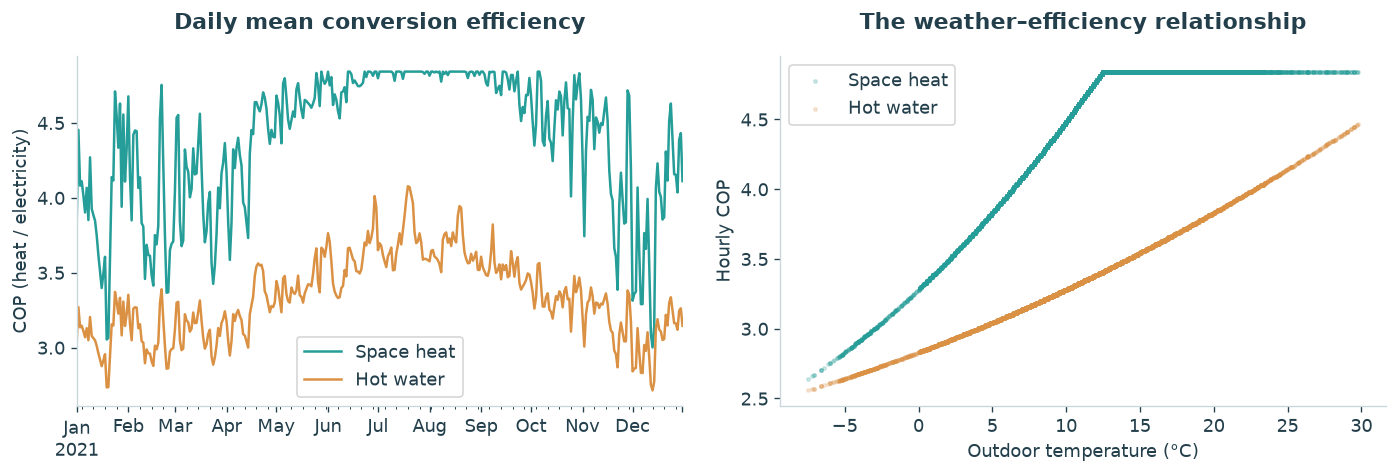

In [6]:
cop=read('enermap/heat_pump_cop_hourly.csv',parse_dates=['timestamp_utc']).set_index('timestamp_utc')
fig,ax=plt.subplots(1,2,figsize=(12,4.3))
cop[['COP_space_heat','COP_dhw']].resample('D').mean().rename(columns={'COP_space_heat':'Space heat','COP_dhw':'Hot water'}).plot(ax=ax[0],color=[TEAL,GOLD])
ax[0].set(title='Daily mean conversion efficiency',ylabel='COP (heat / electricity)',xlabel='')
ax[1].scatter(cop.T_out_C,cop.COP_space_heat,s=4,alpha=.2,color=TEAL,label='Space heat')
ax[1].scatter(cop.T_out_C,cop.COP_dhw,s=4,alpha=.2,color=GOLD,label='Hot water')
ax[1].set(title='The weather–efficiency relationship',xlabel='Outdoor temperature (°C)',ylabel='Hourly COP');ax[1].legend()
finish(fig,'enermap_cop')

## 5 · What has actually been checked?

The run records **16 physics tests, 120 accounting tests and a passed interface import**.
The current baseline uses 34 construction groups × three median size representatives;
306 stochastic cases feed the stock estimate, with 102 deterministic reference cases.
R1 and R2 each have 306 paired simulations. No annual meter calibration was applied.

The annual gas/electricity comparisons are useful diagnostics, but were inspected during
development: they are not an untouched holdout test. The modelled electricity peak is
not validated against hourly measurements. Three stochastic draws and roof-exposure
variation remain limitations.

In [7]:
print('Completion record:')
display(pd.Series({k:completion[k] for k in ['calibration','representation_method','baseline_simulations','retrofit_simulations','interface_import_passed','physics_tests','accounting_tests']}).to_frame('Recorded value'))
baseline=js('enermap/baseline_summary.json')
display(pd.Series(baseline.get('metrics',{})).to_frame('Baseline diagnostic'))
# Sum of hourly-average kW over one-hour intervals gives kWh.
by_hour=hourly.groupby('package_id')[['space_heat_kw','hot_water_heat_kw','non_heating_electricity_kw']].sum()
by_year=annual.groupby('package_id')[['space_heat_kWh','hot_water_kWh','non_heating_elec_kWh']].sum()
relative_error=np.abs(by_hour.to_numpy()-by_year.to_numpy())/by_year.to_numpy()
assert relative_error.max()<1e-5
assert (hourly.groupby('package_id').size()==8760).all()
assert clusters.dwelling_count.sum()==57300
print(f'Packaged hourly/annual reconciliation: maximum relative error {relative_error.max():.2e}')

Completion record:


,Recorded value
calibration,False
representation_method,cluster_median_construction_three_median_areas_v1
baseline_simulations,408
retrofit_simulations,612
interface_import_passed,True
physics_tests,16
accounting_tests,120


,Baseline diagnostic
gas_MAPE,0.072
elec_MAPE,0.103
gas_bias,-0.053
elec_bias,0.029
gas_WAPE_pct,7.261
elec_WAPE_pct,11.160
gas_NMBE_pct,-5.414
elec_NMBE_pct,1.321
gas_R2_predictive,0.898
elec_R2_predictive,0.697


Packaged hourly/annual reconciliation: maximum relative error 3.65e-11


## What this makes possible next

The optimiser can choose a share of each **fabric × heating-system** option in each
cluster. For a cluster, those shares must sum to one. Demand follows the selected
package profile; costs follow eligible physical quantities and heating capacity.
Electricity, fuel and heat remain distinct but coupled balances.

The next modelling milestone is to rerun PyPSA-LAEP on this release and then replay the
selected design hourly. The import check alone does not establish an optimised solution.
See [scope and units](../docs/scope.md) and the [source manifest](../docs/source_manifest.json).